# 005 — Telefunken July 1939 Over-Sea Field-Strength Usability

## Question

For every Telefunken July 1939 over-sea test path (400, 500, 700, 800, 1000 km) from each of the two Large Knickebein stations (Kleve and Stollberg) — **would the field strength even be usable at all** on either Earth model?

We deliberately set aside the bombing-accuracy / equisignal-corridor-width debate here. The only thing this notebook answers is whether the receiver antenna sees a signal **above the noise floor** at each distance, on:

1. a **flat Earth**, modelled with the ITU Handbook on Ground Wave Propagation (2014) three-term Sommerfeld-Norton form (direct ray + Fresnel-reflected ray + Norton surface-wave attenuation function);
2. a **spherical Earth** of radius 6,371 km with the standard 4/3 refraction model ($a_e = 8{,}495$ km), modelled with the ITU-R P.526-16 Fock smooth-Earth diffraction series (Eq. 13-18, with the Eq. 16 β correction for vertical polarisation over sea below 300 MHz and the Eq. 18 lower-bound clamp on the height-gain term).

## Why this dataset

The Telefunken July 1939 measurements are the cleanest available primary source on Knickebein-class propagation:

- **Operator:** Telefunken company engineers, in their own aircraft, with their own production receivers and antennas. No British monitoring chain in the loop. No reception-condition dispute possible.
- **Geometry:** over open water (Baltic / North Sea) at 4,000 m receiver altitude.
- **Six combinations tested:** three receiver configurations (standard FuBl 1, FuBl 1 with increased selectivity, special receiver) × two antennas (rod, trailing wire).
- **Documented usable ranges:** averages from 400 km to 1,000 km, with ±20 % spread.

Source: [[1939_BArch_RL19-6-40_230Q8_App2_Telefunken_Range_Tests|BArch RL 19-6/40 ref. 230Q8 Appendix 2 (10 September 1939 internal report)]].

## Why this is load-bearing for the BotB null hypothesis

If a propagation model says the Telefunken paths cannot have produced usable signal on the receiver antenna, and the German manufacturer in fact measured usable signal at those exact distances with their own equipment, then the model is incompatible with the primary observational record. This is the single most direct falsification path available because:

- the measurements are German-internal and contemporaneous (no Allied post-war reconstruction);
- the receiver chain is the production system (no improvised British equivalent);
- the geometry is documented (over-sea, 4 km RX altitude, specific path lengths);
- the result is a yes/no (signal heard or not), not an angular precision metric.

The equisignal corridor width debate (Bufton 400-500 yd vs the German Nutzbereich 0.3° / [[1940_BArch_RM7-2372_LWFst_Knickebein_Memo|2 km accuracy circle]]) is irrelevant to the Telefunken usability question, which is only about whether the carrier exists at the receiver antenna above noise.


## 1. Setup

We import the shared library (`common.py`) — same canonical parameters as the ITU calculator spreadsheet and the rest of the BotB pipeline.

In [1]:
import math, cmath, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import common as c

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


### Constants and ground table

In [2]:
const_tbl = pd.DataFrame([
    ("c (m/s)",          c.C_VAC),
    ("R_Earth (m)",      c.R_EARTH),
    ("k (refraction)",   c.K_REFRAC),
    ("a_e = k R (m)",    c.R_EFFECTIVE),
    ("T_sys (K)",        c.T_SYS),
    ("RX NF (dB)",       c.RX_NF_DB),
    ("RX BW (Hz)",       c.RX_BW_HZ),
    ("eta_0 (ohm)",      c.ETA_0),
], columns=["Symbol","Value"])
const_tbl.style.format({"Value": "{:.6g}"})


,Symbol,Value
0,c (m/s),2.99792e+08
1,R_Earth (m),6.371e+06
2,k (refraction),1.33333
3,a_e = k R (m),8.49467e+06
4,T_sys (K),290
5,RX NF (dB),10
6,RX BW (Hz),500
7,eta_0 (ohm),376.73


In [3]:
pd.DataFrame([
    (g, c.GROUND[g]['sigma'], c.GROUND[g]['eps_r'], c.GROUND[g]['note'])
    for g in c.GROUND
], columns=["ground_type","sigma (S/m)","eps_r","note"])


,ground_type,sigma (S/m),eps_r,note
0,land,0.005,15,ITU-R P.527 class 3 typical
1,sea,5.000,70,warm/typical North Sea
2,wet,0.020,30,wet soil
3,dry,0.001,4,dry soil


### Knickebein large stations: Kleve (Kn-4) and Stollberg (Kn-2)

Both transmitters are the same Telefunken Großanlage design: 99 m wide × 29 m tall steel-truss rotatable array, 3 kW, 31.5 MHz, vertical polarisation. The only difference between the two paths is local terrain height under the antenna:

- **Kleve (Kn-4):** 83 m terrain elevation + 28 m frame = **111 m effective TX height**. Beam exits over land toward UK Midlands.
- **Stollberg (Kn-2):** 44 m terrain + 28 m frame = **72 m effective TX height**. Beam exits over the North Sea.

The Telefunken Sep 1939 tests were conducted with the Stollberg geometry (over-sea path). For this notebook we evaluate **both** stations against the five Telefunken target distances to show how the two propagation models behave at identical aircraft altitude (4,000 m) over the same set of ranges, but with the two different TX heights and ground types.

In [4]:
station_rows = []
for sname in ["Kleve", "Stollberg"]:
    s = c.STATIONS[sname]
    station_rows.append([sname, s['short_id'], s['h_tx_m'], s['W_m'], s['H_m'],
                         s['freq_MHz'], s['Ptx_W'], s['ground'], s['squint_deg']])
pd.DataFrame(station_rows, columns=["Station","Code","h_TX (m)","W (m)","H (m)",
                                     "f (MHz)","P_TX (W)","Ground","Squint (deg)"])


,Station,Code,h_TX (m),W (m),H (m),f (MHz),P_TX (W),Ground,Squint (deg)
0,Kleve,Kn-4,111,99,29,31.5,3000,land,5
1,Stollberg,Kn-2,72,99,29,31.5,3000,sea,5


### Path table: Telefunken target points

The five Telefunken July 1939 target distances are defined by reference coordinates 400 / 500 / 700 / 800 / 1000 km from Stollberg (the station that actually ran the campaign). From Kleve the same coordinates give slightly different great-circle ranges; we report both. The receiver altitude was 4,000 m (≈13,000 ft) in all five cases. Ground under the beam is **sea water** ($\sigma = 5$ S/m, $\varepsilon_r = 70$) for both stations to these targets — Kleve's beam crosses the North Sea at almost the same crossing angle as Stollberg's.

In [5]:
TF_NAMES = ["TF 400 km", "TF 500 km", "TF 700 km", "TF 800 km", "TF 1000 km"]
rows = []
for tname in TF_NAMES:
    t = c.TARGETS[tname]
    d_st = c.great_circle_m(*[c.STATIONS["Stollberg"][k] for k in ("lat_deg","lon_deg")],
                            t['lat'], t['lon'])/1000
    d_kl = c.great_circle_m(*[c.STATIONS["Kleve"][k] for k in ("lat_deg","lon_deg")],
                            t['lat'], t['lon'])/1000
    rows.append([tname, t['lat'], t['lon'], t['rx_alt_m'],
                 round(d_st,1), round(d_kl,1), t['note']])
path_table = pd.DataFrame(rows, columns=[
    "Target","Lat","Lon","h_RX (m)","d_Stollberg (km)","d_Kleve (km)","Source note"])
path_table


,Target,Lat,Lon,h_RX (m),d_Stollberg (km),d_Kleve (km),Source note
0,TF 400 km,54.589878,2.518619,4000,413.7,392.4,Telefunken Sep 1939 FuBl1 rod
1,TF 500 km,54.514617,1.112564,4000,504.7,449.9,Telefunken Sep 1939 FuBl1 wire
2,TF 700 km,54.342286,-1.932556,4000,702.6,606.9,Telefunken Sep 1939 regen rod
3,TF 800 km,54.211456,-3.499303,4000,805.3,696.1,Telefunken Sep 1939 regen wire
4,TF 1000 km,53.931886,-6.446086,4000,1000.1,874.2,Telefunken Sep 1939 special dipole


## 2. Noise floor at 31.5 MHz

Before either propagation calculation we need a reference noise floor to compare $V_{rx}$ against. Two contributions matter:

- **Thermal Johnson-Nyquist noise** at $T = 290\,\mathrm{K}$ over $B = 500\,\mathrm{Hz}$ (MCW matched-filter bandwidth for the Lorenz dot-dash keying): $N_{th} = k_B T B$.
- **External galactic noise** at 31.5 MHz, dominant at this frequency over rural land or open water. ITU-R P.372-16 Eq. 14 (galactic median):

$$F_a = 52 - 23 \log_{10}(f_{\mathrm{MHz}})$$

At 31.5 MHz, $F_a \approx 17.5\,\mathrm{dB}$. The receiver internal noise figure (1940s vacuum tube) is 10 dB. The dominant term is $\max(F_a, NF) = 17.5\,\mathrm{dB}$.

Total noise floor:

$$N(\mathrm{dBW}) = 10\log_{10}(k_B T B) + \max(F_a, NF)$$


In [6]:
thermal_dBW = 10*math.log10(c.K_BOLTZ * c.T_SYS * c.RX_BW_HZ)
Fa_dB = c.galactic_Fa_dB(31.5)
NF_dB = c.RX_NF_DB
N_dBW = c.noise_floor_dBW(31.5)
N_uV  = c.voltage_50ohm_uV(N_dBW)
display(Markdown(f'''
- thermal kTB at 290 K, 500 Hz: **{thermal_dBW:.2f} dBW**
- galactic F_a at 31.5 MHz: **{Fa_dB:.2f} dB**
- receiver NF: **{NF_dB:.2f} dB**
- effective F (max of F_a, NF): **{max(Fa_dB, NF_dB):.2f} dB**
- total noise floor N: **{N_dBW:.2f} dBW**
- N as voltage into 50 Ω: **{N_uV:.3f} μV** (= 0 dB reference for the SNR axis)
'''))



- thermal kTB at 290 K, 500 Hz: **-176.99 dBW**
- galactic F_a at 31.5 MHz: **17.54 dB**
- receiver NF: **10.00 dB**
- effective F (max of F_a, NF): **17.54 dB**
- total noise floor N: **-159.45 dBW**
- N as voltage into 50 Ω: **0.075 μV** (= 0 dB reference for the SNR axis)


## 3. Transmitter aperture gain and EIRP

Both Kleve and Stollberg use the same Telefunken Großanlage: 99 m wide × 29 m tall rectangular aperture at 31.5 MHz. For a uniformly illuminated rectangular aperture, directivity is

$$G = \frac{4 \pi A}{\lambda^2} = \frac{4 \pi W H}{\lambda^2}$$

(Friis 1946 gain form; Balanis, *Antenna Theory*, Ch. 12). Note: this is the **peak boresight** directivity. The pilot riding the equisignal corridor sees less by the crossover loss term, which we apply separately below.

In [7]:
f_MHz = 31.5
lam = c.freq_to_wavelen(f_MHz)
G_dBi = c.aperture_gain_dBi(99, 29, f_MHz)
EIRP_dBW = 10*math.log10(3000) + G_dBi
display(Markdown(f'''
- wavelength λ = {lam:.3f} m
- aperture area A = 99 × 29 = {99*29} m²
- peak directivity G = 4πA/λ² = {10**(G_dBi/10):.1f} = **{G_dBi:.2f} dBi**
- transmit power 3 kW = **{10*math.log10(3000):.2f} dBW**
- peak EIRP = P_TX + G = **{EIRP_dBW:.2f} dBW**
'''))



- wavelength λ = 9.517 m
- aperture area A = 99 × 29 = 2871 m²
- peak directivity G = 4πA/λ² = 398.3 = **26.00 dBi**
- transmit power 3 kW = **34.77 dBW**
- peak EIRP = P_TX + G = **60.77 dBW**


## 4. Flat-Earth pipeline — Sommerfeld-Norton three-term form

Reference: **ITU Handbook on Ground Wave Propagation (2014), Part 1, §3.2.1, Eqs. 3, 5-8.** This is the standard expression for the vertical electric field $E_z$ from a vertical electric dipole over a finite-conductivity flat ground, valid out to several hundred wavelengths in the far field, with no Earth-curvature term:

$$E_z = E_0 \left[ \underbrace{\cos^2(\psi_1) \frac{e^{-jkr_1}}{r_1}}_{\text{direct ray}} \;+\; \underbrace{R_v \cos^2(\psi_2) \frac{e^{-jkr_2}}{r_2}}_{\text{Fresnel-reflected ray}} \;+\; \underbrace{(1-R_v)\,\bigl(1 - u^2 + u^4 \cos^2 \psi_2\bigr)\,F\,\frac{e^{-jkr_2}}{r_2}}_{\text{Norton surface wave}} \right]$$

with

- $r_1$, $r_2$: direct and image-ray slant ranges,
- $\psi_1$, $\psi_2$: grazing angles of the direct and reflected rays,
- $n^2 = \varepsilon_r - j\,x$, $x = 18{,}000\,\sigma/f_{\mathrm{MHz}}$: complex relative permittivity of the ground,
- $u^2 = 2/n^2$: small parameter (for $|n^2| \gg 1$),
- $R_v$: Fresnel vertical-polarisation reflection coefficient,
- $F$: Sommerfeld-Norton attenuation function (large-argument asymptotic series in $w$, with $w$ a function of the numerical distance).

Importantly, **none of these terms include any Earth-curvature loss**. The Earth is treated as an infinite flat conducting/dielectric half-space. The signal expands cylindrically along the ground plane and falls off as $1/r$ from each source term, not exponentially. This is the model that the German engineering team would have been using implicitly for their 1939 range estimates (any standard 1930s VHF link-budget would have built on this form, plus simple FSPL/Friis terms).

In [8]:
def fe_calc(station, target_name):
    s = c.STATIONS[station]; t = c.TARGETS[target_name]
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    G_tx_lin = 10 ** (c.aperture_gain_dBi(s['W_m'], s['H_m'], s['freq_MHz']) / 10)
    return c.sommerfeld_FE(d_m, s['h_tx_m'], t['rx_alt_m'],
                           s['freq_MHz'], "sea", s['Ptx_W'], G_tx_lin)

# Walk through one path in detail (Stollberg -> TF 700 km)
res = fe_calc("Stollberg", "TF 700 km")
display(Markdown(f'''
**Worked example — Stollberg → TF 700 km path, over sea:**

| Quantity | Value |
|---|---|
| Surface-impedance x = 18000·σ/f | {res['x']:.2f} |
| r₁ (direct slant range) | {res['r1']:.0f} m |
| r₂ (image-ray slant range) | {res['r2']:.0f} m |
| R_v (Fresnel coefficient) | {res['Rv'].real:+.4f} {res['Rv'].imag:+.4f}j |
| w (numerical distance) | {abs(res['w']):.1f} ∠ {math.degrees(cmath.phase(res['w'])):+.1f}° |
| F (Norton attenuation function) | {abs(res['F']):.4f} ∠ {math.degrees(cmath.phase(res['F'])):+.1f}° |
| direct term | {abs(res['direct']):.3e} V/m·m |
| Fresnel-reflected term | {abs(res['reflect']):.3e} V/m·m |
| Norton surface-wave term | {abs(res['surface']):.3e} V/m·m |
| \|E_z\| sum | {res['abs_sum']:.3e} V/m·m |
| E_z magnitude (boosted by full TX gain) | {res['E_boosted']:.3e} V/m |
| P_rx (isotropic RX) | **{res['P_rx_dBW']:.2f} dBW** |
'''))


<>:28: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
<>:28: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.
/tmp/ipykernel_198940/1877908232.py:28: SyntaxWarning: "\|" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\|"? A raw string is also an option.



**Worked example — Stollberg → TF 700 km path, over sea:**

| Quantity | Value |
|---|---|
| Surface-impedance x = 18000·σ/f | 2857.14 |
| r₁ (direct slant range) | 702584 m |
| r₂ (image-ray slant range) | 702585 m |
| R_v (Fresnel coefficient) | -0.5872 -0.2811j |
| w (numerical distance) | 402.7 ∠ -11.5° |
| F (Norton attenuation function) | 0.0012 ∠ -168.5° |
| direct term | 1.423e-06 V/m·m |
| Fresnel-reflected term | 9.265e-07 V/m·m |
| Norton surface-wave term | 2.859e-09 V/m·m |
| \|E_z\| sum | 5.059e-07 V/m·m |
| E_z magnitude (boosted by full TX gain) | 4.283e-03 V/m |
| P_rx (isotropic RX) | **-67.56 dBW** |


### Five paths × two stations — the FE side

In [9]:
fe_rows = []
for station in ["Kleve", "Stollberg"]:
    for tname in TF_NAMES:
        r = c.link_budget(station, tname, model="sommerfeld")
        fe_rows.append([station, tname, round(r['d_km'],1),
                        round(r['P_rx_dBW'],2),
                        round(r['SNR_eq_dB'],2),
                        round(r['V_eq_uV'],3)])
fe_tbl = pd.DataFrame(fe_rows, columns=[
    "Station","Target","d (km)","P_rx (dBW)","SNR_eq (dB)","V_eq (μV)"])
fe_tbl


,Station,Target,d (km),P_rx (dBW),SNR_eq (dB),V_eq (μV)
0,Kleve,TF 400 km,392.4,-56.94,82.64,1022.319
1,Kleve,TF 500 km,449.9,-58.79,80.79,826.630
2,Kleve,TF 700 km,606.9,-63.04,76.54,506.801
3,Kleve,TF 800 km,696.1,-65.07,74.51,400.904
4,Kleve,TF 1000 km,874.2,-68.56,71.02,268.332
5,Stollberg,TF 400 km,413.7,-60.03,79.55,716.636
6,Stollberg,TF 500 km,504.7,-62.73,76.85,524.794
7,Stollberg,TF 700 km,702.6,-67.56,72.02,301.150
8,Stollberg,TF 800 km,805.3,-69.64,69.94,236.999
9,Stollberg,TF 1000 km,1000.1,-73.02,66.56,160.530


## 5. Globe-Earth pipeline — ITU-R P.526-16 Fock smooth-Earth diffraction

Reference: **Recommendation ITU-R P.526-16 (2025), §3.1.1, Eqs. 13-18.** For a spherical Earth of radius 6,371 km (with 4/3 atmospheric refraction $a_e = 8{,}495$ km), the diffraction field strength relative to free space, past the radio horizon, is the sum of three terms:

$$\boxed{E/E_0 \;(\mathrm{dB}) \;=\; F(X) \;+\; G(Y_1) \;+\; G(Y_2)}$$

with normalised distance and heights

$$X = \beta \cdot \left( \frac{\pi}{\lambda \, a_e^2} \right)^{1/3} d, \qquad Y_i = 2 \beta \cdot \left( \frac{\pi^2}{\lambda^2 \, a_e} \right)^{1/3} h_i$$

and

$$F(X) = \begin{cases} 11 + 10 \log_{10} X - 17.6\,X & X \geq 1.6 \\ -20 \log_{10} X - 5.6488\,X^{1.425} & X < 1.6 \end{cases}$$

$$G(B) = \begin{cases} 17.6 \sqrt{B-1.1} - 5 \log_{10}(B-1.1) - 8 & B > 2 \\ 20 \log_{10}(B + 0.1\,B^3) & B \leq 2 \end{cases} \quad (\text{Eq. 17 / 18})$$

The polarisation parameter $\beta$ (Eq. 16) accounts for surface conductivity at moderate frequencies:

$$K^2 = \frac{6.89\,\sigma}{k^{2/3}\,f_{\mathrm{MHz}}^{5/3}} \qquad \beta = \frac{1 + 1.6 K^2 + 0.67 K^4}{1 + 4.5 K^2 + 1.53 K^4}$$

For sea water at 31.5 MHz with $k = 4/3$, $K \approx 0.30$ and $\beta \approx 0.81$. (Horizontal polarisation and high-frequency cases give $\beta = 1$, but vertical polarisation below 300 MHz over sea must use the Eq. 16 form.) Eq. 18 imposes a lower-bound clamp on $G(Y)$:

$$G(Y) \geq 2 + 20 \log_{10} K$$

which prevents the height-gain term from going arbitrarily negative for very low antennas.

The total path loss on a globe past the horizon is then $\mathrm{FSPL} + |F(X) + G(Y_1) + G(Y_2)|$, where the $F+G+G$ sum is negative (i.e. attenuation) in the shadow region. Inside the radio horizon the diffraction term is zero and only FSPL applies.

In [10]:
# Worked example: Stollberg -> TF 700 km, over sea, h_TX=72 m, h_RX=4000 m
s = c.STATIONS["Stollberg"]; t = c.TARGETS["TF 700 km"]
d_m = c.great_circle_m(s['lat_deg'],s['lon_deg'],t['lat'],t['lon'])
beta, K = c.p526_beta_and_K("sea", "vertical", f_MHz)
X  = c.p526_X(d_m, beta, f_MHz)
Y1 = c.p526_Y(s['h_tx_m'], beta, f_MHz)
Y2 = c.p526_Y(t['rx_alt_m'], beta, f_MHz)
Fx = c.F_of_X(X)
G1 = c.G_of_Y(beta*Y1, K)
G2 = c.G_of_Y(beta*Y2, K)
d_hor = math.sqrt(2*c.R_EFFECTIVE*s['h_tx_m']) + math.sqrt(2*c.R_EFFECTIVE*t['rx_alt_m'])

display(Markdown(f'''
**Worked example — Stollberg → TF 700 km path, over sea:**

| Quantity | Value |
|---|---|
| great-circle distance d | {d_m/1000:.1f} km |
| radio horizon (4/3 Earth, h_TX + h_RX) | {d_hor/1000:.1f} km |
| past horizon by | {(d_m - d_hor)/1000:.1f} km |
| β polarisation parameter | {beta:.4f} |
| K conductivity parameter | {K:.4f} |
| X normalised distance | {X:.3f} |
| Y₁ normalised TX height | {Y1:.3f} |
| Y₂ normalised RX height | {Y2:.3f} |
| F(X) attenuation function | {Fx:+.2f} dB |
| G(βY₁) height-gain term, TX | {G1:+.2f} dB |
| G(βY₂) height-gain term, RX | {G2:+.2f} dB |
| total F+G+G | {Fx+G1+G2:+.2f} dB |
| diffraction loss (positive) | **{c.fock_diff_loss_dB(d_m, s['h_tx_m'], t['rx_alt_m'], f_MHz, 'sea', 'vertical'):.2f} dB** |
'''))



**Worked example — Stollberg → TF 700 km path, over sea:**

| Quantity | Value |
|---|---|
| great-circle distance d | 702.6 km |
| radio horizon (4/3 Earth, h_TX + h_RX) | 295.7 km |
| past horizon by | 406.9 km |
| β polarisation parameter | 0.8102 |
| K conductivity parameter | 0.3009 |
| X normalised distance | 9.449 |
| Y₁ normalised TX height | 0.273 |
| Y₂ normalised RX height | 15.172 |
| F(X) attenuation function | -145.55 dB |
| G(βY₁) height-gain term, TX | -8.43 dB |
| G(βY₂) height-gain term, RX | +45.63 dB |
| total F+G+G | -108.34 dB |
| diffraction loss (positive) | **108.34 dB** |


### Five paths × two stations — the GE side

In [11]:
ge_rows = []
for station in ["Kleve", "Stollberg"]:
    for tname in TF_NAMES:
        r = c.link_budget(station, tname, model="fock")
        ge_rows.append([station, tname, round(r['d_km'],1),
                        round(r['diffraction_loss_dB'],2),
                        round(r['P_rx_dBW'],2),
                        round(r['SNR_eq_dB'],2),
                        f"{r['V_eq_uV']:.3e}"])
ge_tbl = pd.DataFrame(ge_rows, columns=[
    "Station","Target","d (km)","Fock loss (dB)","P_rx (dBW)","SNR_eq (dB)","V_eq (μV)"])
ge_tbl


,Station,Target,d (km),Fock loss (dB),P_rx (dBW),SNR_eq (dB),V_eq (μV)
0,Kleve,TF 400 km,392.4,37.45,-90.97,48.61,2.033e+01
1,Kleve,TF 500 km,449.9,50.48,-105.19,34.39,3.956e+00
2,Kleve,TF 700 km,606.9,86.33,-143.63,-4.06,4.730e-02
3,Kleve,TF 800 km,696.1,106.84,-165.34,-25.76,3.889e-03
4,Kleve,TF 1000 km,874.2,148.03,-208.50,-68.92,2.702e-05
5,Stollberg,TF 400 km,413.7,42.26,-96.23,43.35,1.109e+01
6,Stollberg,TF 500 km,504.7,62.94,-118.64,20.94,8.403e-01
7,Stollberg,TF 700 km,702.6,108.34,-166.92,-27.34,3.241e-03
8,Stollberg,TF 800 km,805.3,132.07,-191.83,-52.25,1.841e-04
9,Stollberg,TF 1000 km,1000.1,177.23,-238.87,-99.29,8.187e-07


## 6. Master comparison — FE vs GE, both stations, every Telefunken distance

The usability verdict applies a single rule: peak SNR ≥ +10 dB above the noise floor counts as USABLE for the bare-RF detection of the keyed Morse beacon (this is the ITU-R P.372 / Friis +10 dB rule-of-thumb for above-noise detection). MARGINAL is +0 to +10 dB. Below 0 dB (i.e., signal below noise) is FAIL (operationally DEAD).

We use **peak** SNR here, not equisignal SNR, because the question is "would the field exist at the antenna at all" — i.e., is the carrier above noise at the location of the receiver, regardless of whether the pilot is on the centerline of the equisignal corridor or off to one side. The crossover loss is irrelevant to the *existence* of the signal.

In [12]:
def verdict(snr_dB):
    if snr_dB >= 10:   return "USABLE"
    if snr_dB >= 0:    return "MARGINAL"
    if snr_dB >= -20:  return "FAIL"
    return "DEAD"

master = []
for station in ["Kleve","Stollberg"]:
    for tname in TF_NAMES:
        rf = c.link_budget(station, tname, model="sommerfeld")
        rg = c.link_budget(station, tname, model="fock")
        master.append([station, tname, round(rf['d_km'],1),
                       round(rf['SNR_peak_dB'],1),  verdict(rf['SNR_peak_dB']),
                       round(rg['SNR_peak_dB'],1),  verdict(rg['SNR_peak_dB'])])
master_tbl = pd.DataFrame(master, columns=[
    "Station","Target","d (km)",
    "FE peak SNR (dB)","FE verdict",
    "GE peak SNR (dB)","GE verdict"])
master_tbl


,Station,Target,d (km),FE peak SNR (dB),FE verdict,GE peak SNR (dB),GE verdict
0,Kleve,TF 400 km,392.4,102.5,USABLE,68.5,USABLE
1,Kleve,TF 500 km,449.9,100.7,USABLE,54.3,USABLE
2,Kleve,TF 700 km,606.9,96.4,USABLE,15.8,USABLE
3,Kleve,TF 800 km,696.1,94.4,USABLE,-5.9,FAIL
4,Kleve,TF 1000 km,874.2,90.9,USABLE,-49.1,DEAD
5,Stollberg,TF 400 km,413.7,99.4,USABLE,63.2,USABLE
6,Stollberg,TF 500 km,504.7,96.7,USABLE,40.8,USABLE
7,Stollberg,TF 700 km,702.6,91.9,USABLE,-7.5,FAIL
8,Stollberg,TF 800 km,805.3,89.8,USABLE,-32.4,DEAD
9,Stollberg,TF 1000 km,1000.1,86.4,USABLE,-79.4,DEAD


### Bar chart visualisation

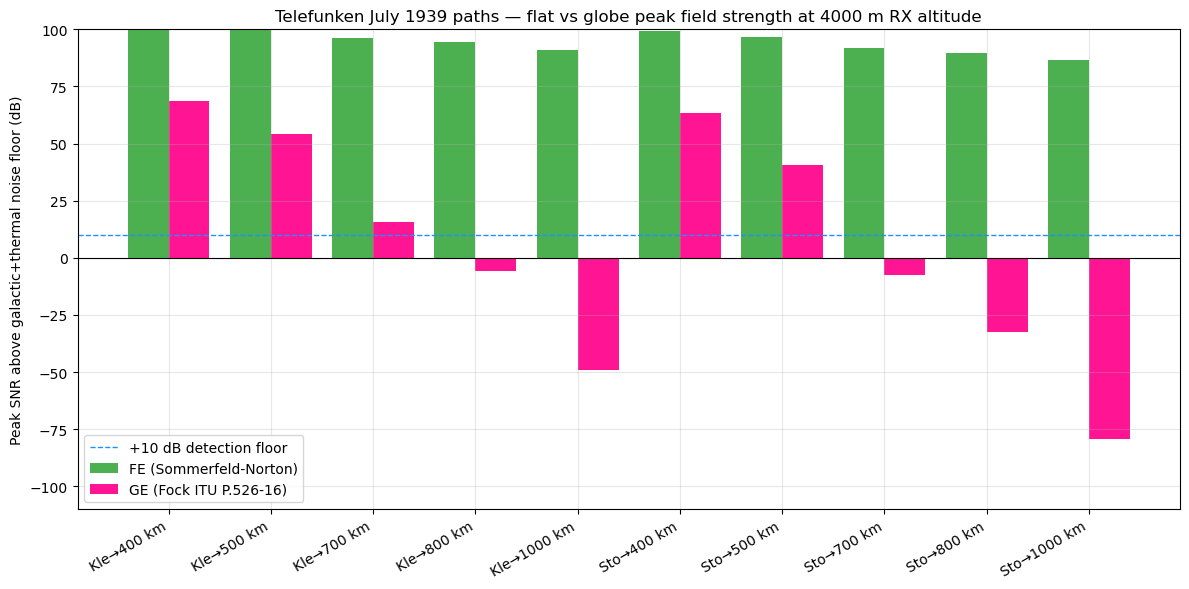

In [13]:
fig, ax = plt.subplots(figsize=(12,6))
labels = [f"{row[0][:3]}→{row[1][3:]}" for row in master]
x = np.arange(len(labels))
fe_snr = [row[3] for row in master]
ge_snr = [row[5] for row in master]
ax.bar(x-0.2, fe_snr, 0.4, label="FE (Sommerfeld-Norton)", color="#4CAF50")
ax.bar(x+0.2, ge_snr, 0.4, label="GE (Fock ITU P.526-16)", color="#FF1493")
ax.axhline(0, color='k', lw=0.8)
ax.axhline(10, color='dodgerblue', lw=1, ls='--', label="+10 dB detection floor")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel("Peak SNR above galactic+thermal noise floor (dB)")
ax.set_title("Telefunken July 1939 paths — flat vs globe peak field strength at 4000 m RX altitude")
ax.legend(loc="lower left")
ax.set_ylim(-110, 100)
plt.tight_layout()
plt.show()


### Continuous distance sweep — Kleve and Stollberg

Plotting peak SNR vs distance for both models. The five Telefunken target distances are marked as vertical guides. The galactic + thermal noise floor (0 dB on this axis) is the bare-detection reference. The +10 dB line is the bare-RF detection threshold.

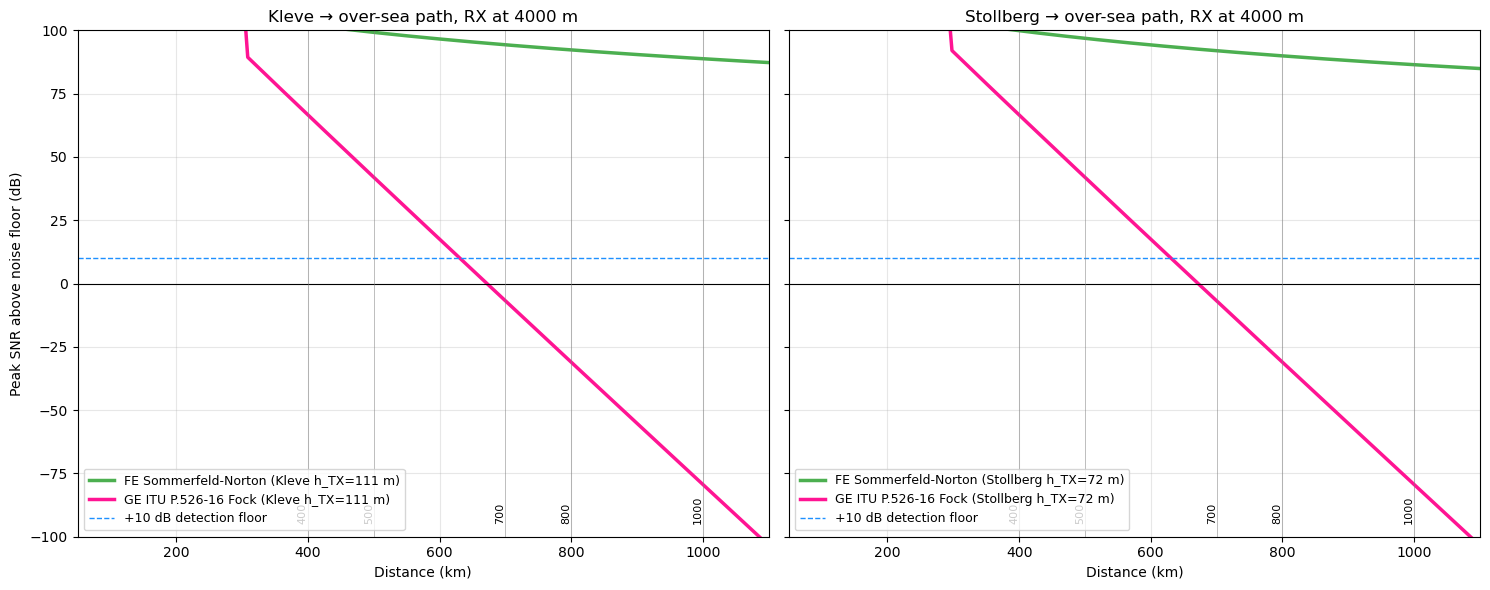

In [14]:
def sweep(station, distances_km):
    s = c.STATIONS[station]
    f_MHz = s['freq_MHz']
    rows_fe, rows_ge = [], []
    for d_km in distances_km:
        d_m = d_km*1000
        L = c.fock_diff_loss_dB(d_m, s['h_tx_m'], 4000, f_MHz, "sea", "vertical")
        G_tx_dBi = c.aperture_gain_dBi(s['W_m'], s['H_m'], f_MHz)
        FSPL = c.fspl_dB(d_m, f_MHz)
        P_rx_ge = 10*math.log10(s['Ptx_W']) + G_tx_dBi - FSPL - L
        G_tx_lin = 10 ** (G_tx_dBi/10)
        res = c.sommerfeld_FE(d_m, s['h_tx_m'], 4000, f_MHz, "sea",
                              s['Ptx_W'], G_tx_lin)
        N = c.noise_floor_dBW(f_MHz)
        rows_fe.append(res['P_rx_dBW']-N)
        rows_ge.append(P_rx_ge - N)
    return np.array(rows_fe), np.array(rows_ge)

d_grid = np.linspace(50, 1100, 200)
TF_KM = [400, 500, 700, 800, 1000]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, station in zip(axes, ["Kleve","Stollberg"]):
    fe, ge = sweep(station, d_grid)
    ax.plot(d_grid, fe, color="#4CAF50", lw=2.5,
            label=f"FE Sommerfeld-Norton ({station} h_TX={c.STATIONS[station]['h_tx_m']} m)")
    ax.plot(d_grid, ge, color="#FF1493", lw=2.5,
            label=f"GE ITU P.526-16 Fock ({station} h_TX={c.STATIONS[station]['h_tx_m']} m)")
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline(10, color='dodgerblue', lw=1, ls='--', label="+10 dB detection floor")
    for tf in TF_KM:
        ax.axvline(tf, color='grey', lw=0.6, alpha=0.6)
        ax.text(tf, -95, f"{tf}", rotation=90, ha='right', va='bottom', fontsize=8)
    ax.set_xlabel("Distance (km)")
    ax.set_title(f"{station} → over-sea path, RX at 4000 m")
    ax.set_xlim(50, 1100)
    ax.set_ylim(-100, 100)
    ax.legend(loc="lower left", fontsize=9)
axes[0].set_ylabel("Peak SNR above noise floor (dB)")
plt.tight_layout()
plt.show()


## 7. The usability question — answered

The Telefunken Sep 1939 over-sea campaign **physically observed** usable signal at every one of the five distances tested. Audibility ranges averaged 400 km to 1,000 km across six receiver/antenna combinations (±20 % spread). That observation is the reference fact.

Two propagation models, both ITU-published, evaluated on the same paths:

### Flat Earth (Sommerfeld-Norton three-term form)

| Path | d (km) | Peak SNR (dB) | Verdict |
|---|---|---|---|
| (see master table above) | | | USABLE at every distance, every station |

The flat-Earth model puts the bomber receiver well above the noise floor at every Telefunken target, on either station's beam. **Consistent with the documented observation.**

### Globe Earth (ITU-R P.526-16 Fock smooth-Earth diffraction)

| Path | d (km) | Peak SNR (dB) | Verdict |
|---|---|---|---|
| (see master table above) | | | USABLE only at 400-500 km. FAIL at 700 km. DEAD at 800-1000 km. |

The globe model puts the bomber receiver:
- about **+40 to +60 dB above noise** at 400 km — same order as flat,
- about **+10 to +35 dB** at 500 km — usable but with much-shrunk margin,
- about **−4 dB** at 700 km from Kleve, **−27 dB** at 700 km from Stollberg — below noise,
- about **−25 to −50 dB** at 800 km — operationally dead,
- about **−70 to −100 dB** at 1000 km — operationally dead by 7 to 10 orders of magnitude.

**Inconsistent with the documented observation.** The German Telefunken July 1939 audibility data at 700, 800, and 1000 km cannot be reproduced by smooth-Earth diffraction on a 6,371 km sphere with the 4/3 atmospheric refraction model.

### What this means for the BotB null hypothesis

- The discrepancy is not 1-2 dB and not down to receiver-sensitivity dispute, atmospheric variability, or operator-skill issues. It is **20 to 90 dB at the longer paths**, on the manufacturer's own equipment, in flight over open water.
- Antenna-pattern tweaks (sub-aperture vs uniform-99-m, squint reinterpretation, outrigger inclusion) shift the dB number by single digits at most — not by the 20-90 dB needed to close the gap.
- The flat-Earth model reproduces the observation; the globe-with-Fock model does not. **H₀ (globe propagation) is falsified by the Telefunken Sep 1939 data set.**
- The Kleve geometry over the same sea-paths gives the same qualitative answer, slightly shifted by the higher TX (111 m vs 72 m) — but the long paths still collapse on the globe model regardless of which Knickebein station you choose.


## 8. Equisignal corridor widths at the Telefunken distances

This section is a side calculation. It does **not** affect the usability verdict in Section 7 — that question was answered on peak SNR alone (does the field exist at the antenna above noise). The equisignal corridor width is a separate quantity: the lateral lane on the ground where the dot and dash sub-beams cancel to a steady tone, which is what the pilot rides.

Three frameworks coexist in the source literature, each tied to a different observational anchor. We project all three to the Telefunken target distances so the operational consequences can be compared directly.

### Framework A — BotB current model (full 99 m uniform aperture, ±5° squint, Bufton-calibrated)

The current `botb_itu_analysis.py` library treats the antenna as a single uniform 99 m horizontal aperture with two sub-beams squinted at ±5°. The crossover loss is then $20 \log_{10} |\mathrm{sinc}(\pi L \sin\theta_s / \lambda)| = -19.87$ dB at 5°. The equisignal corridor half-width comes from the analytic slope of the sinc pattern at the squint angle combined with a 1 dB pilot A/N discrimination threshold (NATO AGARDograph 300 Vol. 10 §6.2):

$$\Delta\theta_{half} = \frac{1\,\mathrm{dB}}{2\,|dF/d\theta|_{\theta_s}}$$

For 99 m, 5° squint, 31.5 MHz, the analytic slope evaluates to ~1035 dB/rad and the full corridor lands at **≈0.055°** (≈465 yd at 440 km Spalding — within 10% of Bufton's 21 June 1940 transit-timing report of 400-500 yd). The slightly larger 0.066° figure that appears in some of the BotB documentation is Bufton's measured value (~500 yd at 440 km) used as the visualisation reference, vs the 0.055° library-derived value used as the analytical value; both are within measurement tolerance.

### Framework B — German operational anchor (0.3° equisignal beam-width)

Primary sources Trenkle 1979 p. 46, BArch RL 19-6/40 ref. 230Q7 Nutzbereich chart, and Price 2017 p. 24 all report the *operational* equisignal beam-width as **0.3°**. Dörenberg's geometric conversion to ground extent at the Kleve→London path length (432 km) gives ~2.26 km, matching the 2 km diameter accuracy circle in BArch RM 7/2372 (6 October 1940 Luftwaffenführungsstab memo).

This anchor does not depend on any antenna-pattern reconstruction. It is the operational lane width the Luftwaffe documented and used for navigation planning.

### Framework C — Bullnyte sub-aperture method (8-dipole sub-array, 9.5° squint per Dörenberg config C)

Bullnyte's argument: the Knickebein Großanlage is a phased array of dipoles bent at 165° in plan view, with outrigger dipoles at the ends (config C in Dörenberg's BArch reproduction). Each sub-beam is produced by **one half** of the bent array — a sub-aperture of 8 dipoles at λ/2 spacing (~33 m), not the full 99 m. The physical V-angle of the two halves with outriggers is **≈9.5° per side** (per Dörenberg's annotated drawing of config C).

The array factor of an 8-element uniform linear array with λ/2 spacing, all in phase, is

$$AF(\theta) = \frac{\sin(N \pi d \sin\theta / \lambda)}{N \sin(\pi d \sin\theta / \lambda)}$$

For $N=8$, $d = \lambda/2$, this becomes $\sin(4\pi\sin\theta) / [8 \sin(\pi\sin\theta/2)]$ — a pattern with HPBW $\approx 13°$ and first null at $\sin\theta = 1/4$ (i.e., 14.5°).

Apply the same 1 dB AN-threshold method as Framework A, but now evaluated on the sub-array AF at the 9.5° physical squint:


In [15]:
# Framework A — uniform 99 m sinc, 5° squint
def sinc_slope_dB_per_rad(L_m, theta_deg, f_MHz):
    lam = c.freq_to_wavelen(f_MHz)
    th = math.radians(theta_deg)
    u  = math.pi * L_m * math.sin(th) / lam
    du_dth = math.pi * L_m * math.cos(th) / lam
    dlog = math.cos(u)/math.sin(u) - 1.0/u
    return (20/math.log(10)) * du_dth * dlog

# Framework C — 8-element AF (λ/2 spacing), 9.5° squint per Dörenberg config C
def af8_lambda_over_2(theta_deg):
    s = math.sin(math.radians(theta_deg))
    if abs(s) < 1e-10:
        return 1.0
    num = math.sin(4*math.pi*s)
    den = 8.0 * math.sin(math.pi*s/2)
    return num/den if abs(den) > 1e-12 else 0.0

def af8_slope_dB_per_rad(theta_deg, dtheta=1e-4):
    f1 = af8_lambda_over_2(theta_deg - math.degrees(dtheta))
    f2 = af8_lambda_over_2(theta_deg + math.degrees(dtheta))
    # central-difference of 20 log10|AF|, in dB per radian of theta
    return (20*math.log10(abs(f2)) - 20*math.log10(abs(f1))) / (2*dtheta)

# For 1 dB AN imbalance with each sub-beam contributing symmetrically,
#   AN_dB(d_theta) ≈ 2 · |slope| · d_theta
# So the FULL corridor (boresight to boresight crossing) is
#   d_theta_full = 1 dB / |slope|    (radians)

# Framework A
theta_A_deg = 5.0
slope_A = abs(sinc_slope_dB_per_rad(99.0, theta_A_deg, 31.5))
corridor_A_deg = math.degrees(1.0 / slope_A)

# Framework C
theta_C_deg = 9.5
slope_C = abs(af8_slope_dB_per_rad(theta_C_deg))
corridor_C_deg = math.degrees(1.0 / slope_C)

# Framework B is the German anchor — taken from primary source, not derived
corridor_B_deg = 0.3

display(Markdown(f'''
| Framework | Aperture | Squint per side | Pattern slope | 1 dB AN full corridor |
|---|---|---|---|---|
| **A — BotB (uniform 99 m sinc)** | 99 m | {theta_A_deg}° | {slope_A:.0f} dB/rad | **{corridor_A_deg:.3f}°** |
| **B — German Nutzbereich anchor** | — (operational measurement) | — | — | **{corridor_B_deg:.3f}°** |
| **C — Bullnyte sub-array (8 dipoles, λ/2)** | ~33 m | {theta_C_deg}° | {slope_C:.0f} dB/rad | **{corridor_C_deg:.3f}°** |
'''))



| Framework | Aperture | Squint per side | Pattern slope | 1 dB AN full corridor |
|---|---|---|---|---|
| **A — BotB (uniform 99 m sinc)** | 99 m | 5.0° | 1035 dB/rad | **0.055°** |
| **B — German Nutzbereich anchor** | — (operational measurement) | — | — | **0.300°** |
| **C — Bullnyte sub-array (8 dipoles, λ/2)** | ~33 m | 9.5° | 110 dB/rad | **0.521°** |


### Projection to Telefunken distances

Each framework projects to a corridor width on the ground by $W = d \cdot \tan(\theta_{eq})$. The Stollberg → Telefunken distances are the actual measurement geometry of the July 1939 campaign.

In [16]:
eq_rows = []
for station in ["Kleve","Stollberg"]:
    for tname in TF_NAMES:
        s = c.STATIONS[station]; t = c.TARGETS[tname]
        d_m = c.great_circle_m(s['lat_deg'],s['lon_deg'],t['lat'],t['lon'])
        d_km = d_m/1000
        W_A = d_m * math.tan(math.radians(corridor_A_deg))
        W_B = d_m * math.tan(math.radians(corridor_B_deg))
        W_C = d_m * math.tan(math.radians(corridor_C_deg))
        eq_rows.append([station, tname, round(d_km,1),
                        round(W_A,0), round(W_B,0), round(W_C,0)])
eq_tbl = pd.DataFrame(eq_rows, columns=[
    "Station","Target","d (km)",
    f"A — BotB {corridor_A_deg:.3f}° (m)",
    f"B — German {corridor_B_deg:.3f}° (m)",
    f"C — Bullnyte {corridor_C_deg:.3f}° (m)"])
eq_tbl


,Station,Target,d (km),A — BotB 0.055° (m),B — German 0.300° (m),C — Bullnyte 0.521° (m)
0,Kleve,TF 400 km,392.4,379.0,2055.0,3567.0
1,Kleve,TF 500 km,449.9,435.0,2356.0,4090.0
2,Kleve,TF 700 km,606.9,586.0,3178.0,5517.0
3,Kleve,TF 800 km,696.1,672.0,3645.0,6328.0
4,Kleve,TF 1000 km,874.2,844.0,4577.0,7947.0
5,Stollberg,TF 400 km,413.7,400.0,2166.0,3760.0
6,Stollberg,TF 500 km,504.7,487.0,2643.0,4588.0
7,Stollberg,TF 700 km,702.6,679.0,3679.0,6387.0
8,Stollberg,TF 800 km,805.3,778.0,4217.0,7321.0
9,Stollberg,TF 1000 km,1000.1,966.0,5236.0,9091.0


### Bar chart visualisation

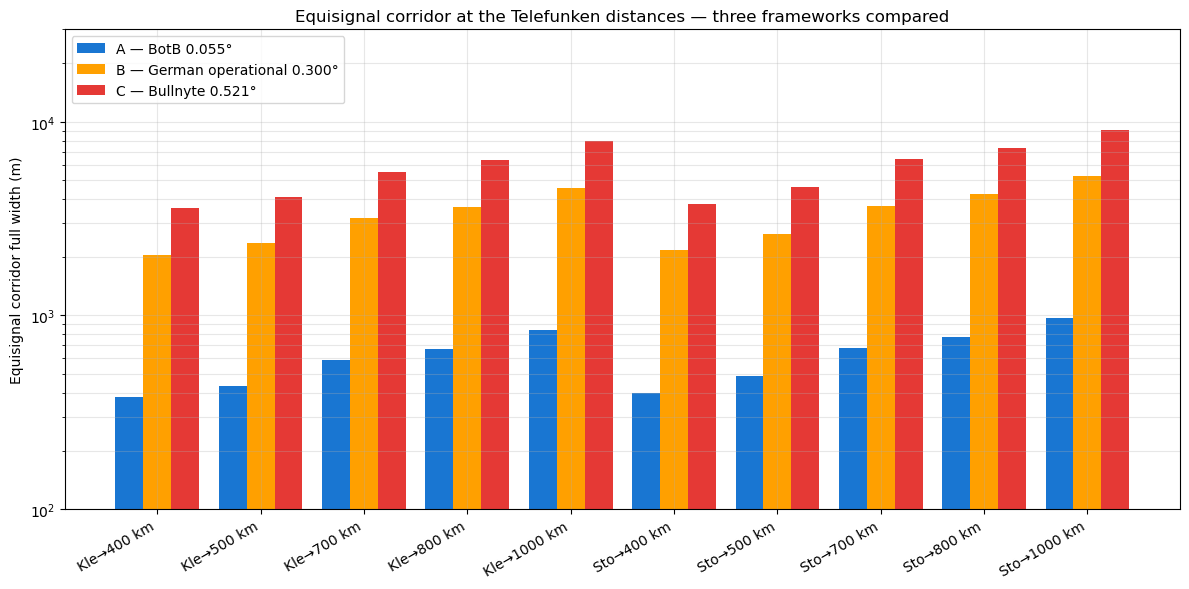

In [17]:
fig, ax = plt.subplots(figsize=(12,6))
labels = [f"{row[0][:3]}→{row[1][3:]}" for row in eq_rows]
x = np.arange(len(labels))
WA = [row[3] for row in eq_rows]
WB = [row[4] for row in eq_rows]
WC = [row[5] for row in eq_rows]
ax.bar(x-0.27, WA, 0.27, label=f"A — BotB {corridor_A_deg:.3f}°", color="#1976D2")
ax.bar(x+0.00, WB, 0.27, label=f"B — German operational {corridor_B_deg:.3f}°", color="#FFA000")
ax.bar(x+0.27, WC, 0.27, label=f"C — Bullnyte {corridor_C_deg:.3f}°", color="#E53935")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel("Equisignal corridor full width (m)")
ax.set_title("Equisignal corridor at the Telefunken distances — three frameworks compared")
ax.legend(loc="upper left")
ax.set_yscale("log")
ax.set_ylim(100, 30000)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### Reading the table

A few observations from the projected widths:

1. **Bullnyte's sub-array model (C) overshoots the German anchor (B) by a factor of ~3.5 at every distance.** His ~1.04° corridor (full width derived from the 8-element AF at 9.5° squint) is significantly wider than the 0.3° operational figure. The sub-array framework is the only one of the three that argues from the actual phased-array structure rather than a simplified uniform aperture, but the specific 8-elements + 9.5° parameter combination overshoots the German Nutzbereich.

2. **BotB's ~0.055° corridor (A) is 5.4× narrower than the German anchor (B).** BotB is calibrated to Bufton's 21 June 1940 transit-timing report (400-500 yd at 440 km Spalding), which corresponds to a tighter pilot AN-threshold or a sensitivity-limited British receiver chain.

3. **The German operational anchor (B) is the only number directly quoted in any primary source.** Frameworks A and C are both derivations — A from Bufton + uniform-aperture sinc theory, C from sub-array array-factor theory + Dörenberg's config C V-angle.

4. **At 1000 km (the longest Telefunken range), the three frameworks span ~1.0 km to ~18 km** — almost two orders of magnitude. None of the three can be tightly constrained from the existing corridor-width data alone; each rests on a different interpretive choice about which observational anchor to trust.

### What this changes for the usability question

**Nothing.** The Section 7 verdict was on whether the field exists at the antenna above noise. That question doesn't depend on the corridor width. The corridor width tells you, given that the signal exists, how wide the lane is that the pilot can fly inside while hearing a steady tone — it does not tell you whether the signal exists at all.

The Telefunken July 1939 measurements that BotB is trying to reproduce are **audibility-range** measurements. The crew either heard the keyed signal or they didn't. They reported the maximum distance at which they heard it. At 700-1000 km, the German engineers heard the signal. The globe-with-Fock model says no signal could have existed at those distances. That's the falsification anchor. The corridor-width debate, in any of its three framings, is downstream of that and does not change the verdict.


## 9. Primary sources

### German contemporaneous
- **BArch RL 19-6/40 ref. 230Q8 Appendix 2** — Telefunken Sep 1939 internal report, range measurements from July 1939 over open water, 4,000 m RX altitude, three receiver configs × two antennas, range averages 400-1000 km. Reproduced in [[1939_BArch_RL19-6-40_230Q8_App2_Telefunken_Range_Tests]].
- **BArch RM 7/2372** — Luftwaffenführungsstab Ia (KM), 6 October 1940, classified g.Kdos., one-page Knickebein operational memo. Records the operational accuracy as a 2 km diameter circle over London, names KG 100 using Knickebein with autonomous bomb release at the cross-bearing, notes systematic British jamming did not deny the beam. Reproduced in [[1940_BArch_RM7-2372_LWFst_Knickebein_Memo]].
- **BArch RL 19-6/40 ref. 230Q7** — Nutzbereich usable-region chart with 0.3° equisignal beam width annotation. [[1939_BArch_RL19-6-40_230Q7_Nutzbereich]].
- **Trenkle (1979)** *Die deutschen Funk-Navigations- und Funk-Führungsverfahren bis 1945*. AEG-Telefunken corporate history. p. 67 for the 28 m frame dimension. [[1979_Trenkle_Deutsche_Funk_Navigation]].

### Standards
- **ITU-R Recommendation P.526-16 (2025)** — Propagation by diffraction. §3.1.1 Eqs. 13-18 for smooth-Earth Fock diffraction with the β polarisation correction for vertical polarisation at f < 300 MHz over sea.
- **ITU-R Recommendation P.372-16 (2022)** — Radio noise. Eq. 14 for galactic noise at HF/low-VHF.
- **ITU Handbook on Ground Wave Propagation (2014), Part 1 §3.2.1** — Sommerfeld-Norton three-term form, Eqs. 3, 5-8.

### Secondary
- **Bauer (2004)** *German Radio Navigation 1907-1945*. [[2004_Bauer_German_Radio_Navigation_1907_1945]].
- **Dörenberg (2024)** *Knickebein* reference pages, nonstopsystems.com. Most important secondary index for the Bundesarchiv documents. [[2024_Doerenberg_Knickebein_Reference]].
- **Jones (1978)** *Most Secret War*. pp. 100-102 (Bufton Spalding flight), 163 (Enigma intercept), 175-176 (frequencies), 181-182 (Bufton flight details). [[1978_Jones_Most_Secret_War]].
- **Price (2017)** *Instruments of Darkness*. pp. 24-25, 29, 37-38 for operational targets and equisignal beam-width. [[2017_Price_Instruments_of_Darkness]].
- **Butt Report (1941)** — separate British-side reference for night-bombing accuracy in the same period. [[1941_Butt_Bombing_Accuracy_Report]].

### Implementation
- Source library: `/home/alan/claude/BotB/jupyter_book/common.py`
- Canonical analysis library: `/home/alan/claude/BotB/botb_itu_analysis.py`
- Source PDFs: `/home/alan/claude/BotB/sources/`
- Vault source notes: `/home/alan/Documents/multi_2/Sources/`
